# DIVINE PROJECT

## IMPORT LIBRARIES

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# LOAD DATA

In [3]:
crime = pd.read_csv('C:\\Users\\Divine\\Desktop\\project\\crime_data_niger_delta.csv')
crime.head()

,Year,Month_reported,State,Crime_rate,Crime_occurrence_frequency,Armed Robbery,Kidnapping,Oil Bunkering,Piracy,Cultism,Human Trafficking,Drug Trafficking,Vandalism,UnemploymentRate,PovertyRate,Most_prevalent_crime
0,2000,1,Abia,23.6,57,Yes,Yes,Yes,No,Yes,No,Yes,No,30,50,Armed Robbery
1,2000,2,Abia,33.9,93,No,Yes,No,Yes,No,No,No,No,30,50,Kidnapping
2,2000,3,Abia,43.7,5,Yes,No,No,Yes,No,Yes,No,Yes,30,50,Armed Robbery
3,2000,4,Abia,37.5,89,Yes,No,No,Yes,No,Yes,Yes,No,30,50,Armed Robbery
4,2000,5,Abia,46.9,24,Yes,No,No,No,No,No,Yes,Yes,30,50,Armed Robbery


# DATA OVERVIEW

In [4]:
crime.head()

,Year,Month_reported,State,Crime_rate,Crime_occurrence_frequency,Armed Robbery,Kidnapping,Oil Bunkering,Piracy,Cultism,Human Trafficking,Drug Trafficking,Vandalism,UnemploymentRate,PovertyRate,Most_prevalent_crime
0,2000,1,Abia,23.6,57,Yes,Yes,Yes,No,Yes,No,Yes,No,30,50,Armed Robbery
1,2000,2,Abia,33.9,93,No,Yes,No,Yes,No,No,No,No,30,50,Kidnapping
2,2000,3,Abia,43.7,5,Yes,No,No,Yes,No,Yes,No,Yes,30,50,Armed Robbery
3,2000,4,Abia,37.5,89,Yes,No,No,Yes,No,Yes,Yes,No,30,50,Armed Robbery
4,2000,5,Abia,46.9,24,Yes,No,No,No,No,No,Yes,Yes,30,50,Armed Robbery


# CLEAN COLUMN NAMES 

In [5]:
crime.columns = (crime.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_"))
crime.columns

Index(['year', 'month_reported', 'state', 'crime_rate',
       'crime_occurrence_frequency', 'armed_robbery', 'kidnapping',
       'oil_bunkering', 'piracy', 'cultism', 'human_trafficking',
       'drug_trafficking', 'vandalism', 'unemploymentrate', 'povertyrate',
       'most_prevalent_crime'],
      dtype='object')

# CRIME TREND OVER THE YEARS (LINE CHART)

## CHECK COLUMS AND CLEAN ROWS

In [6]:
crime.isnull().sum()
crime.drop_duplicates(inplace=True)
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        2484 non-null   int64  
 1   month_reported              2484 non-null   int64  
 2   state                       2484 non-null   object 
 3   crime_rate                  2484 non-null   float64
 4   crime_occurrence_frequency  2484 non-null   int64  
 5   armed_robbery               2484 non-null   object 
 6   kidnapping                  2484 non-null   object 
 7   oil_bunkering               2484 non-null   object 
 8   piracy                      2484 non-null   object 
 9   cultism                     2484 non-null   object 
 10  human_trafficking           2484 non-null   object 
 11  drug_trafficking            2484 non-null   object 
 12  vandalism                   2484 non-null   object 
 13  unemploymentrate            2484 

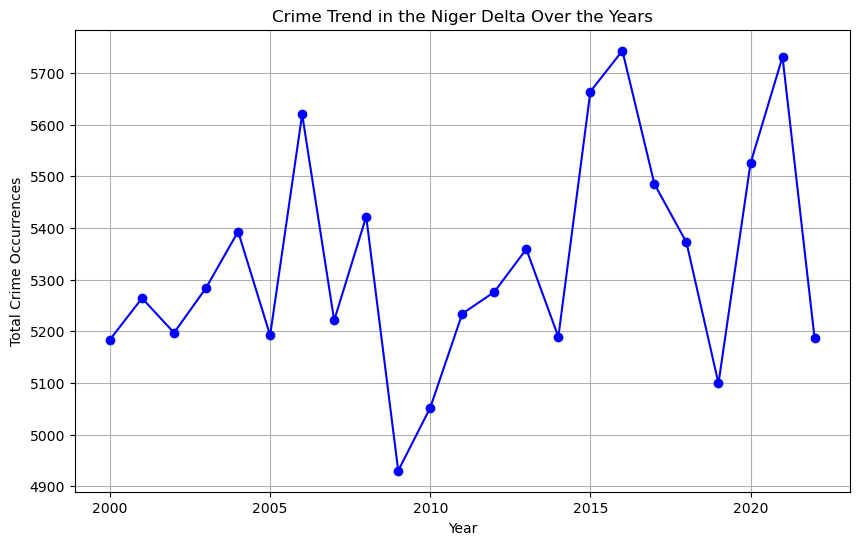

In [7]:
crime_by_year = crime.groupby("year")["crime_occurrence_frequency"].sum()

plt.figure(figsize=(10,6))
plt.plot(crime_by_year.index, crime_by_year.values,color='blue',marker='o')
plt.title("Crime Trend in the Niger Delta Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Crime Occurrences")
plt.grid(True)
plt.show()


# TOTAL CRIME BY STATE (BAR CHART)

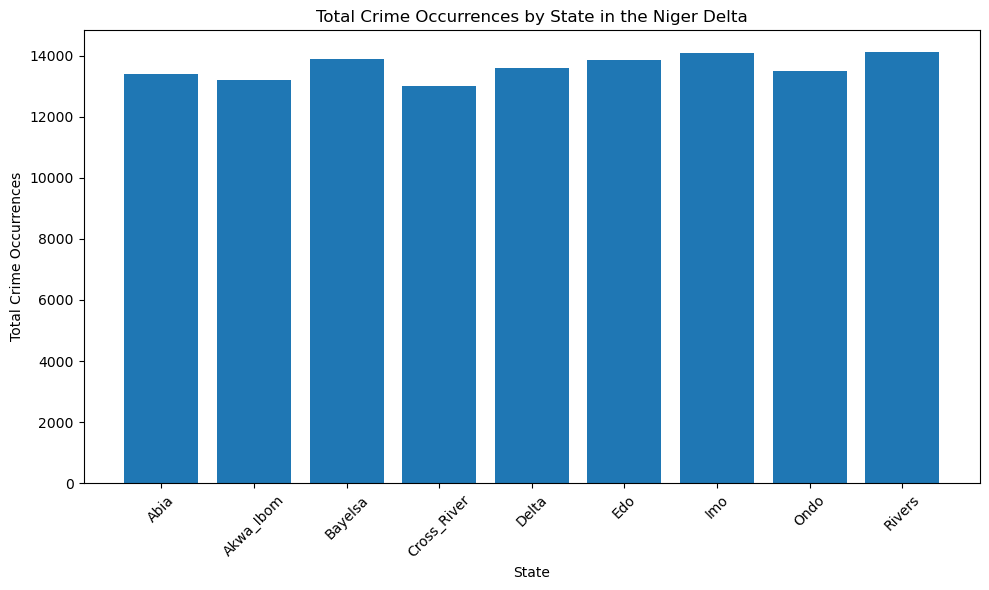

In [8]:
crime_by_state = crime.groupby("state")["crime_occurrence_frequency"].sum()

plt.figure(figsize=(10,6))
plt.bar(crime_by_state.index, crime_by_state.values)
plt.title("Total Crime Occurrences by State in the Niger Delta")
plt.xlabel("State")
plt.ylabel("Total Crime Occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# TOP 5 STATES WITH HIGHEST CRIME

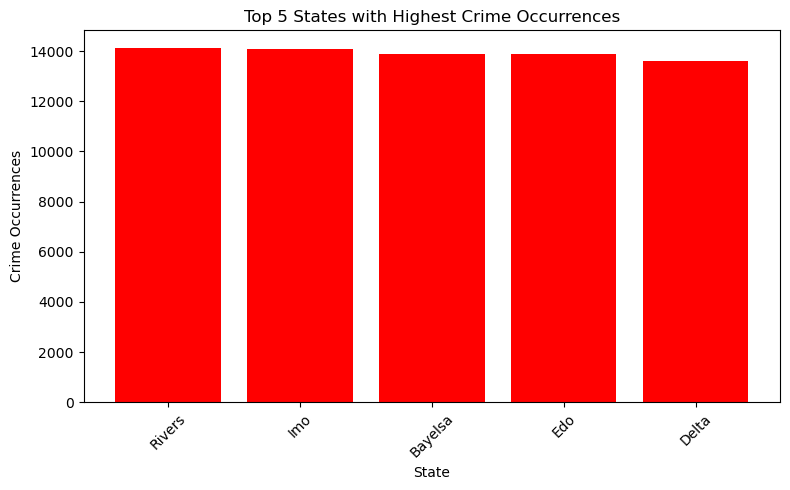

In [9]:
top_5_states = crime_by_state.sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.bar(top_5_states.index, top_5_states.values, color='red')
plt.title("Top 5 States with Highest Crime Occurrences")
plt.xlabel("State")
plt.ylabel("Crime Occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# MOST PREVALENT CRIMES

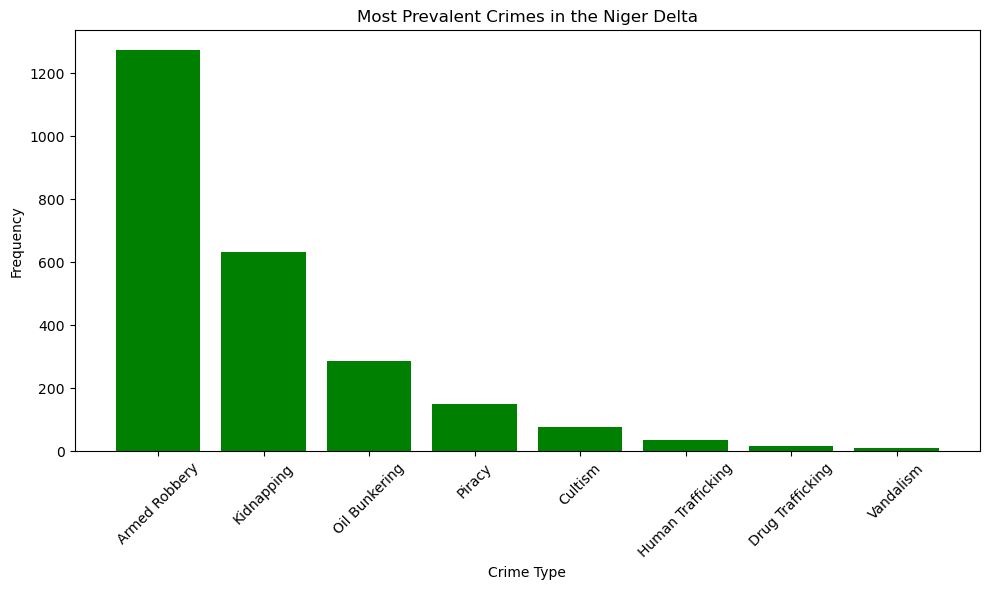

In [10]:
crime_types = crime["most_prevalent_crime"].value_counts()

plt.figure(figsize=(10,6))
plt.bar(crime_types.index, crime_types.values,color = 'green')
plt.title("Most Prevalent Crimes in the Niger Delta")
plt.xlabel("Crime Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# MONTHLY CRIME DISTRIBUTION

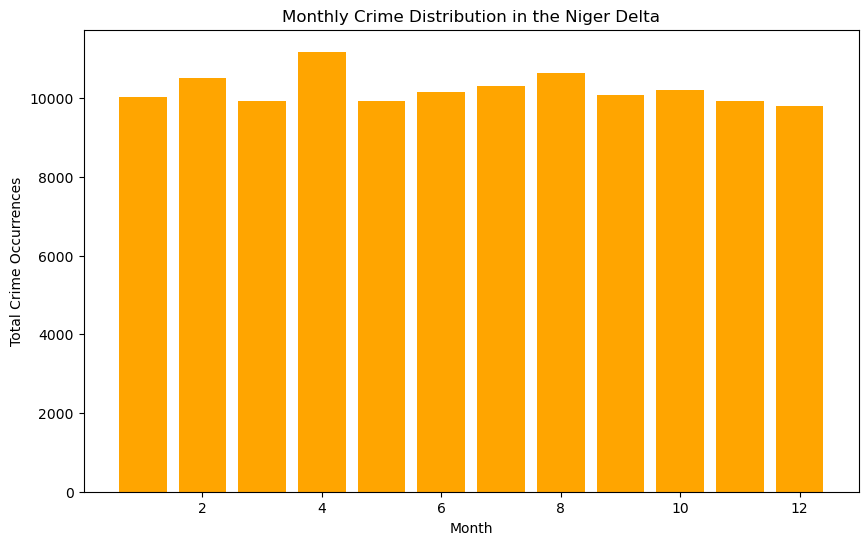

In [11]:
crime_by_month = crime.groupby("month_reported")["crime_occurrence_frequency"].sum()

plt.figure(figsize=(10,6))
plt.bar(crime_by_month.index, crime_by_month.values,color = 'orange')
plt.title("Monthly Crime Distribution in the Niger Delta")
plt.xlabel("Month")
plt.ylabel("Total Crime Occurrences")
plt.show()


# POVERTY RATE VS CRIME (SCATTER PLOT)

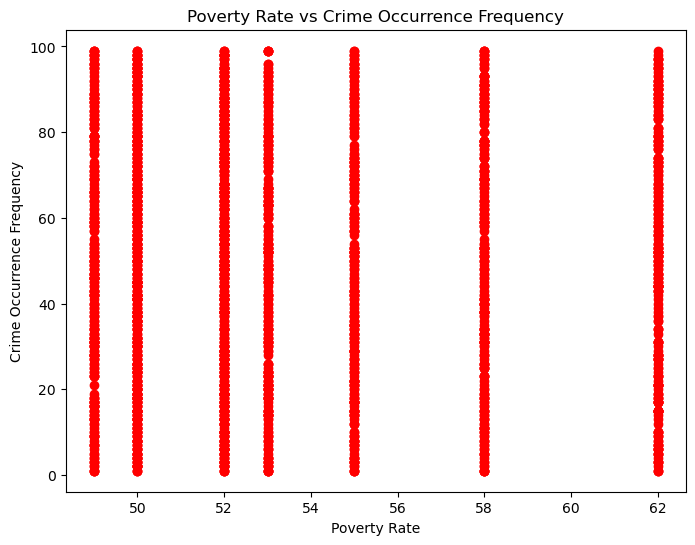

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(
    crime["povertyrate"],
    crime["crime_occurrence_frequency"],
    color = 'red')
    

plt.title("Poverty Rate vs Crime Occurrence Frequency")
plt.xlabel("Poverty Rate")
plt.ylabel("Crime Occurrence Frequency")
plt.show()


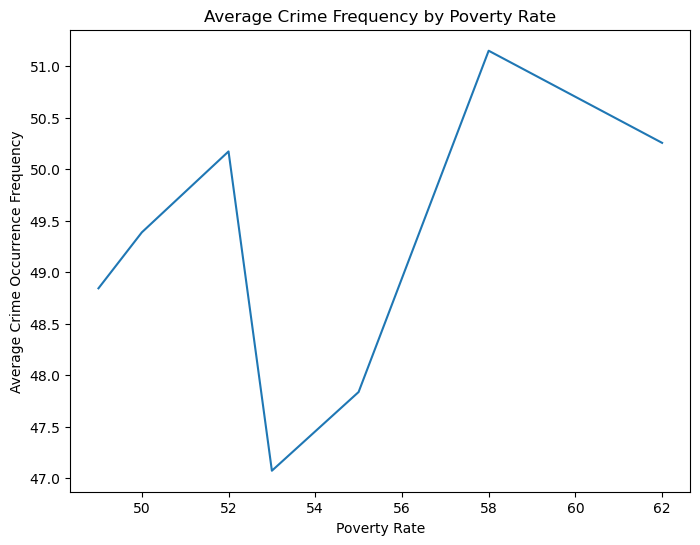

In [13]:
# Group by poverty rate and calculate average crime
avg_crime = crime.groupby("povertyrate")["crime_occurrence_frequency"].mean()

plt.figure(figsize=(8,6))
plt.plot(avg_crime.index, avg_crime.values)

plt.title("Average Crime Frequency by Poverty Rate")
plt.xlabel("Poverty Rate")
plt.ylabel("Average Crime Occurrence Frequency")
plt.show()
